### Imports ###

In [1]:
%reload_ext autoreload
%autoreload 2

import time
import corner
import pickle
from tqdm import tqdm
import matplotlib.pyplot as plt

import numpy as np

import jax
import jax.numpy as jnp
import blackjax
from blackjax.ns.utils import finalise, log_weights
print(jax.devices())

from data import get_data_orbit
from prior import prior_dists_orbit, logprior_orbit, sample_from_priors_orbit
from loglikelihood import loglikelihood_stream, loglikelihood_orbit
from model import jax_stream_model, jax_stream_orbit

[CpuDevice(id=0)]


In [ ]:
from data import get_data_stream

q_true = 0.8
seed   = 42
sigma  = 1
nlive  = 1000
ndim   = 15
queue_size = 100
PATH_SAVE = f'.'

dict_data = get_data_stream(q_true, seed, sigma)

In [2]:
with open('./dns_results.pkl', 'rb') as f:
    data = pickle.load(f)

ValueError: Provided figure has 169 axes, but data has dimensions K=14

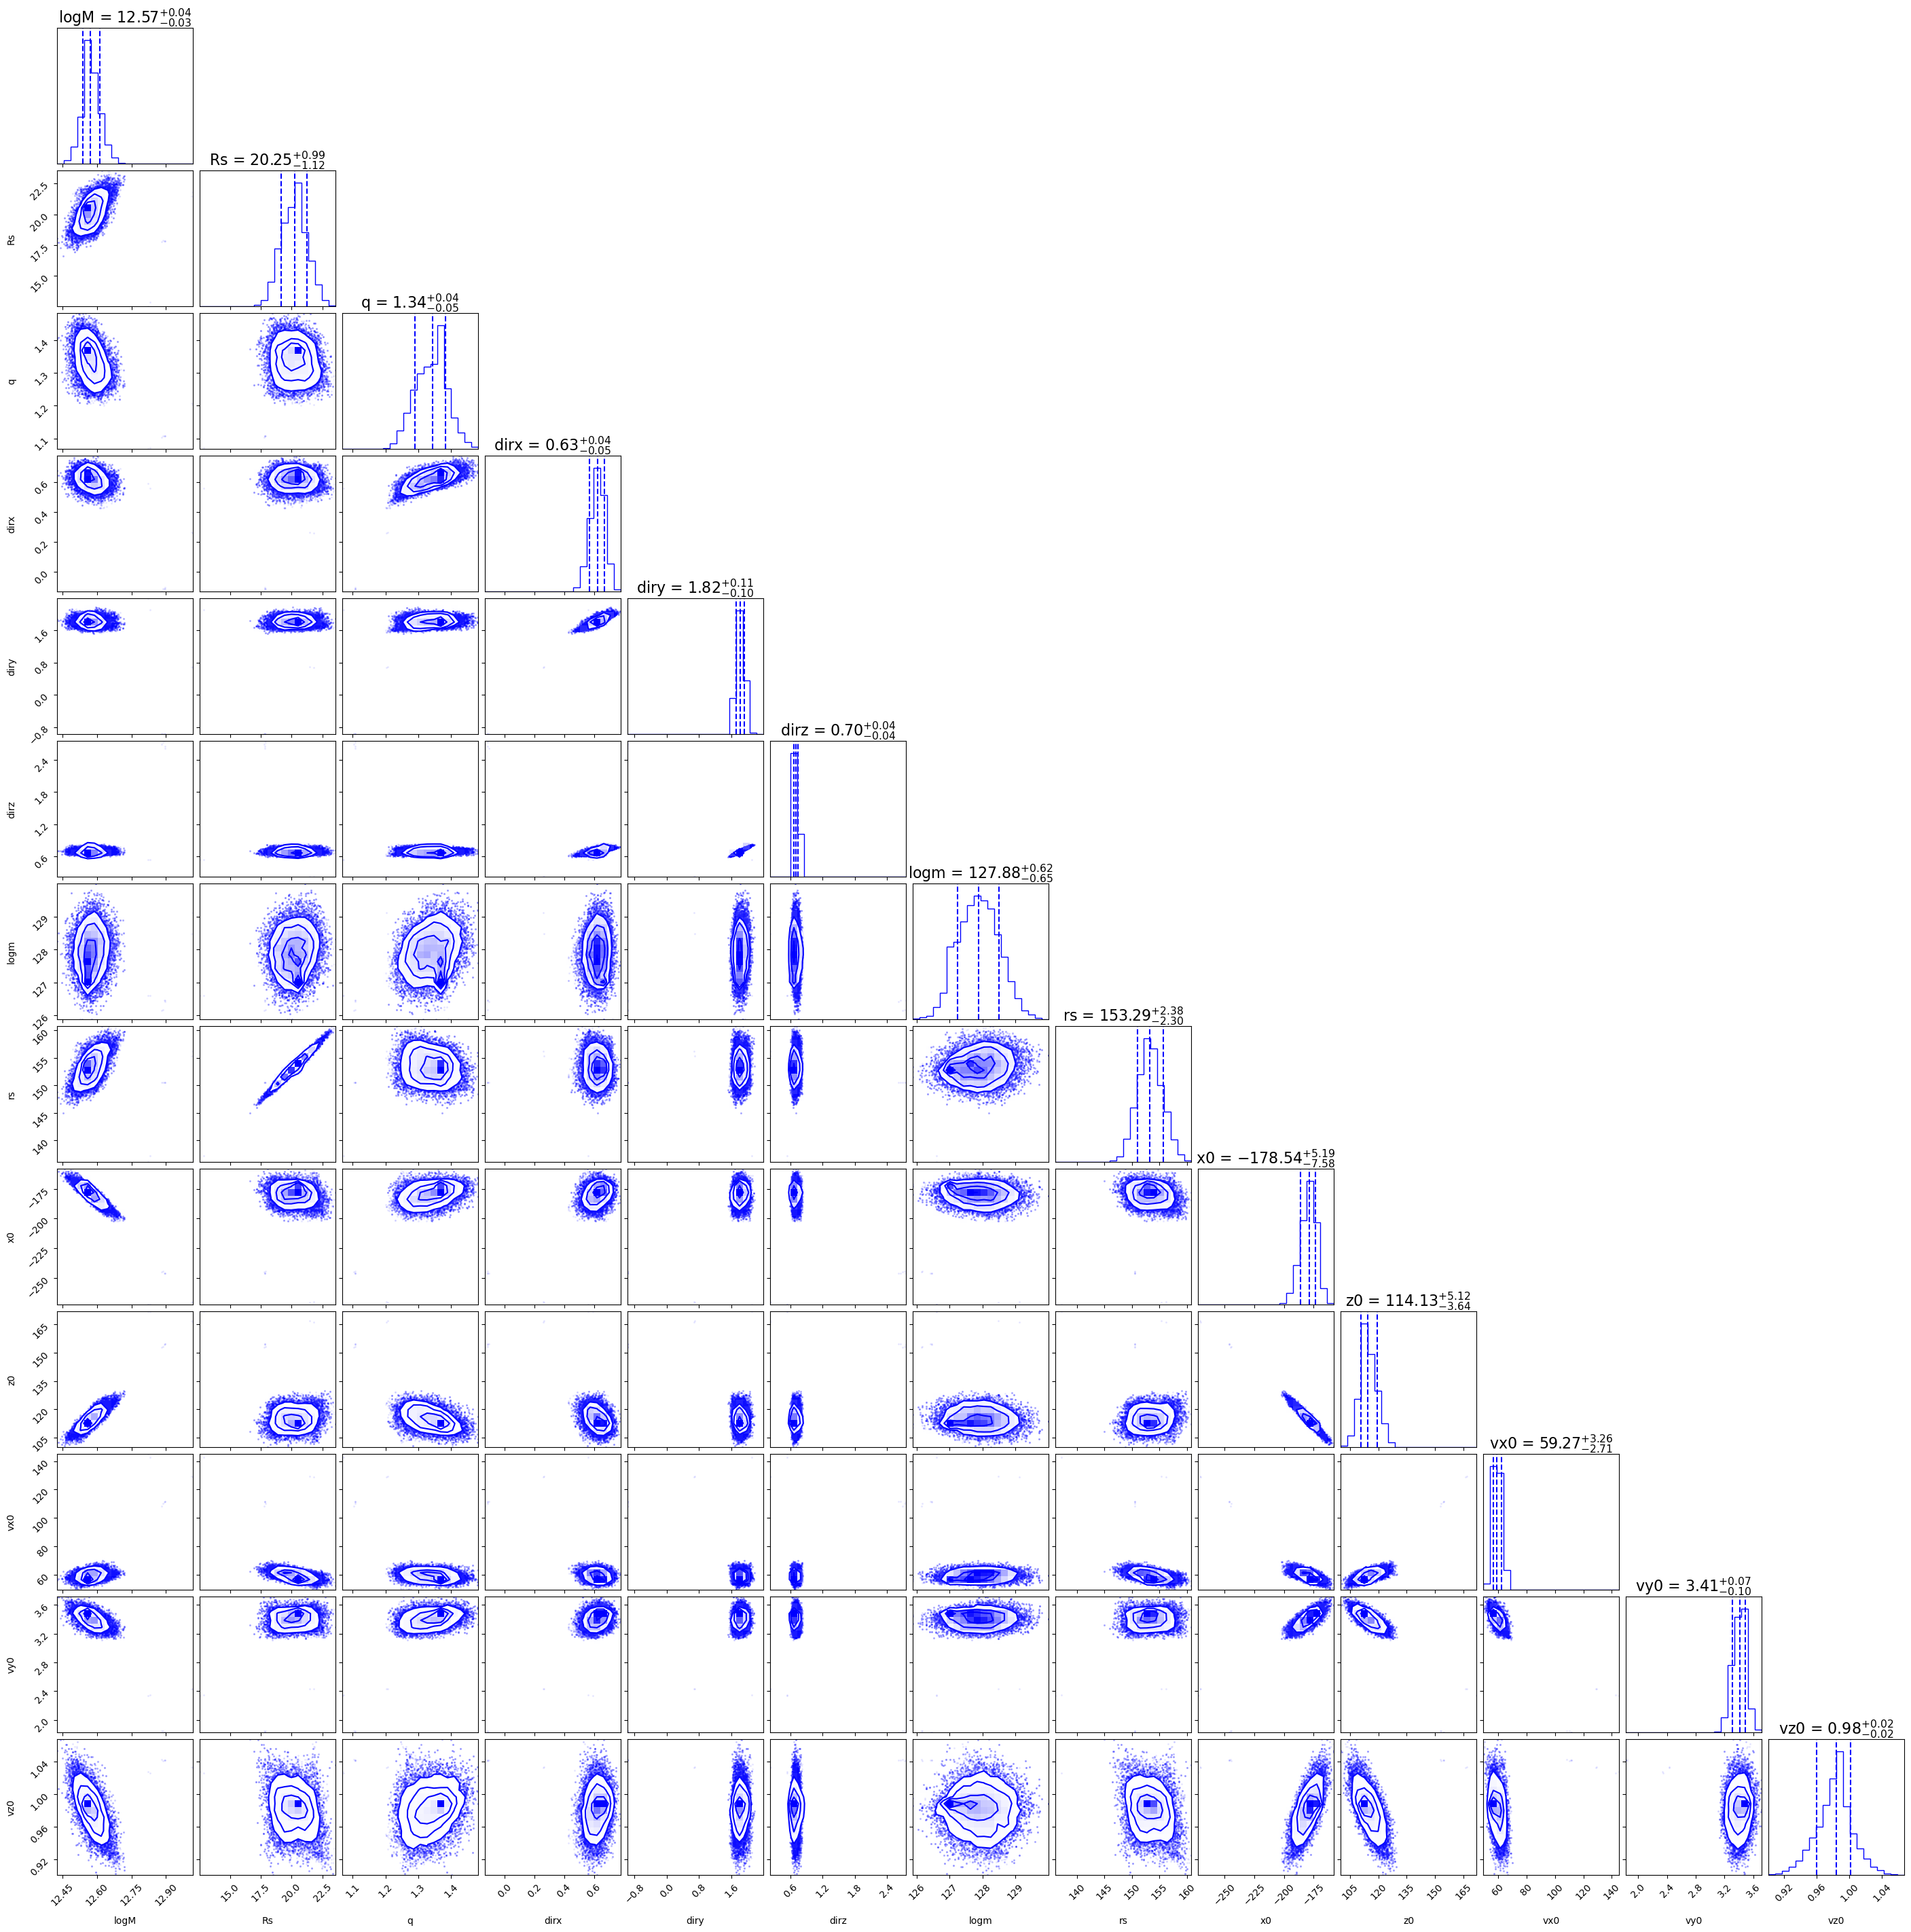

In [5]:
labels = ['logM', 'Rs', 'q', 'dirx', 'diry', 'dirz', 'logm', 'rs', 'x0', 'z0', 'vx0', 'vy0', 'vz0', 'time', 'alpha']
# ground_truth = np.concatenate( [data['params'], [1]])
figure = corner.corner(data['samps'], 
            labels=labels,
            color='blue',
            quantiles=[0.16, 0.5, 0.84],
            show_titles=True, 
            title_kwargs={"fontsize": 16},
            truths=dict_data['params'], 
            truth_color='red')
plt.savefig(f'plots/corner_stream.pdf')
# plt.savefig(f'plots/corner_q0.8_sig1_seed42_nlive100.pdf')

### Get the Data ###

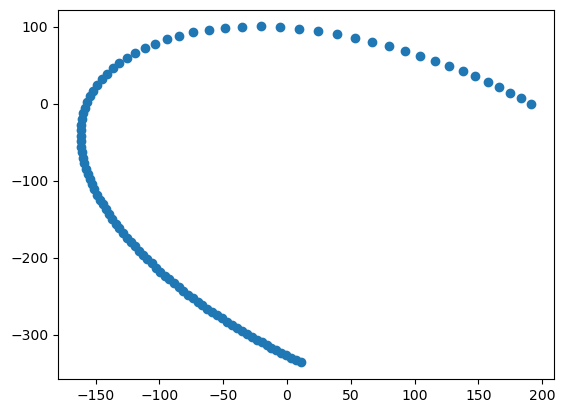

In [2]:
# Get data
q_true = 0.8
seed   = 42
sigma  = 1
n_live = 10
PATH_SAVE = f'./'

dict_data = get_data_orbit(q_true, seed, sigma)
plt.scatter(dict_data['x_stream'], dict_data['y_stream'])

In [3]:
rng_key = jax.random.PRNGKey(0)
rng_key, init_key = jax.random.split(rng_key)

initial_particles = sample_from_priors_orbit(init_key, n_live)

In [4]:
initial_particles.shape

(10, 13)

In [42]:
logl = jax.vmap(lambda p: loglikelihood_orbit(p, dict_data))(initial_particles)

In [45]:
logM, Rs, q, dirx, diry, dirz, x0, z0, vx0, vy0, vz0, time, alpha = initial_particles[1]
dirz = jnp.abs(dirz)
x0   = jnp.abs(x0)
z0   = jnp.abs(z0)
vy0  = jnp.abs(vy0)

y0 = 0.

theta_stream, x_stream, y_stream, vz_stream, r_meds, w_meds, x_meds, y_meds, vz_meds = jax_stream_orbit(logM, Rs, q, dirx, diry, dirz, x0, y0, z0, vx0, vy0, vz0, time, alpha)

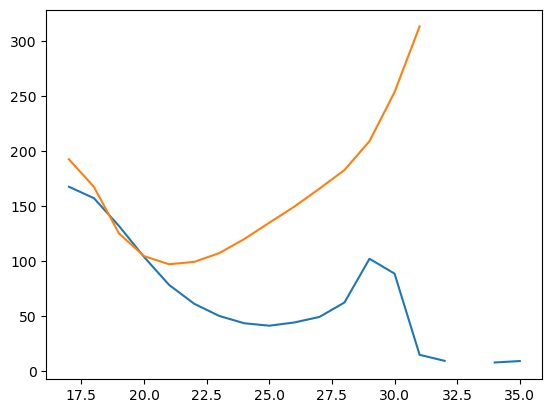

In [46]:
plt.plot(r_meds)
plt.plot(dict_data['r_data'])

In [50]:
jnp.where(jnp.isfinite(logl))[0]

Array([1], dtype=int32)

In [47]:
mask = ~jnp.isnan(dict_data['r_data'])

# Count how many predictions are bad
nan_mask = jnp.isnan(jnp.where(mask, r_meds, 0.0))
n_bad = jnp.sum(nan_mask)

In [48]:
n_bad

Array(0, dtype=int32)

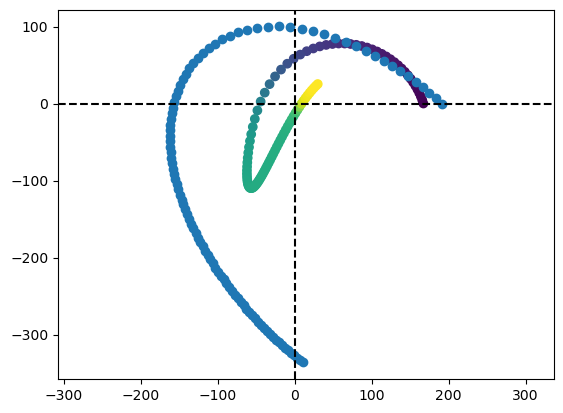

In [49]:
plt.scatter(x_stream, y_stream, c=theta_stream)
plt.scatter(dict_data['x_stream'], dict_data['y_stream'])
plt.axis('equal')
plt.axvline(0, color='k', ls='--')
plt.axhline(0, color='k', ls='--')

### Load the Samples ###

In [ ]:
samps_100 = np.load('samples/samps_q0.8_sig1_seed42_nlive100.npy')
samps_500 = np.load('samples/samps_q0.8_sig1_seed42_nlive500.npy')

### Plot the Posteriors ###

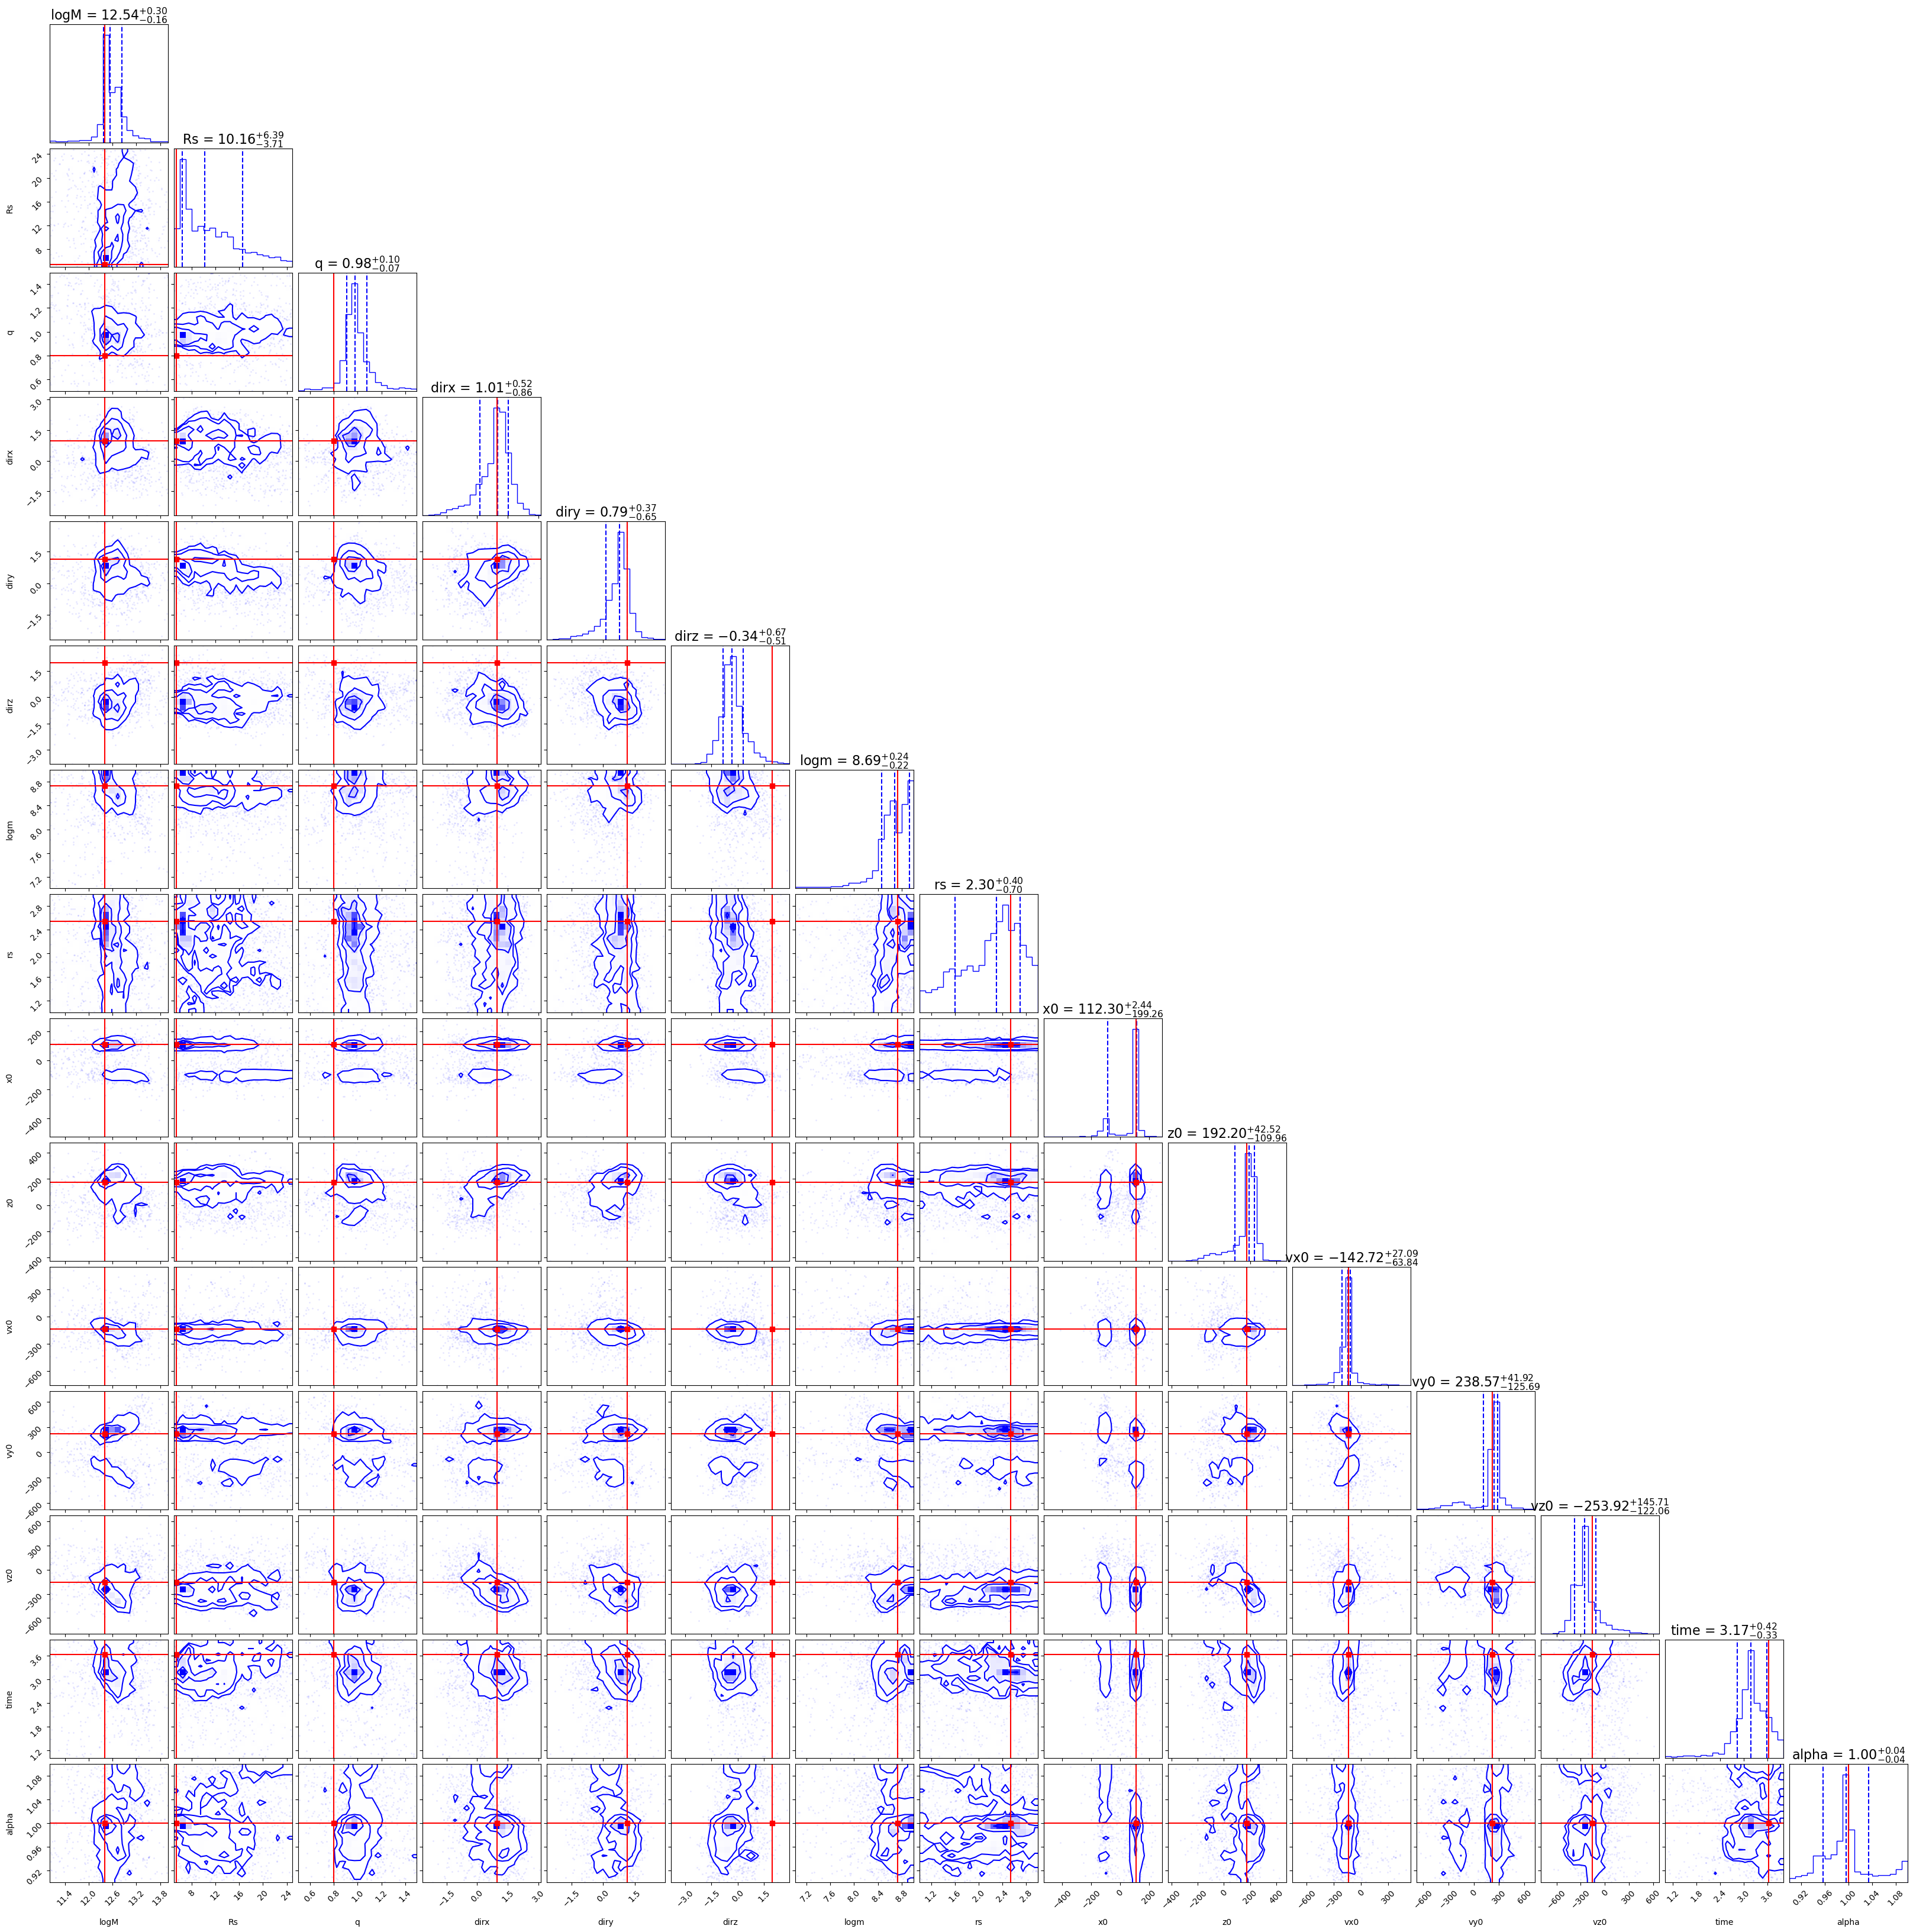

In [35]:
labels = ['logM', 'Rs', 'q', 'dirx', 'diry', 'dirz', 'logm', 'rs', 'x0', 'z0', 'vx0', 'vy0', 'vz0', 'time', 'alpha']
ground_truth = np.concatenate( [dict_data['params'], [1]])
figure = corner.corner(samps_100, 
            labels=labels,
            color='blue',
            quantiles=[0.16, 0.5, 0.84],
            show_titles=True, 
            title_kwargs={"fontsize": 16},
            truths=ground_truth, 
            truth_color='red')
plt.savefig(f'plots/corner_q0.8_sig1_seed42_nlive100.pdf')

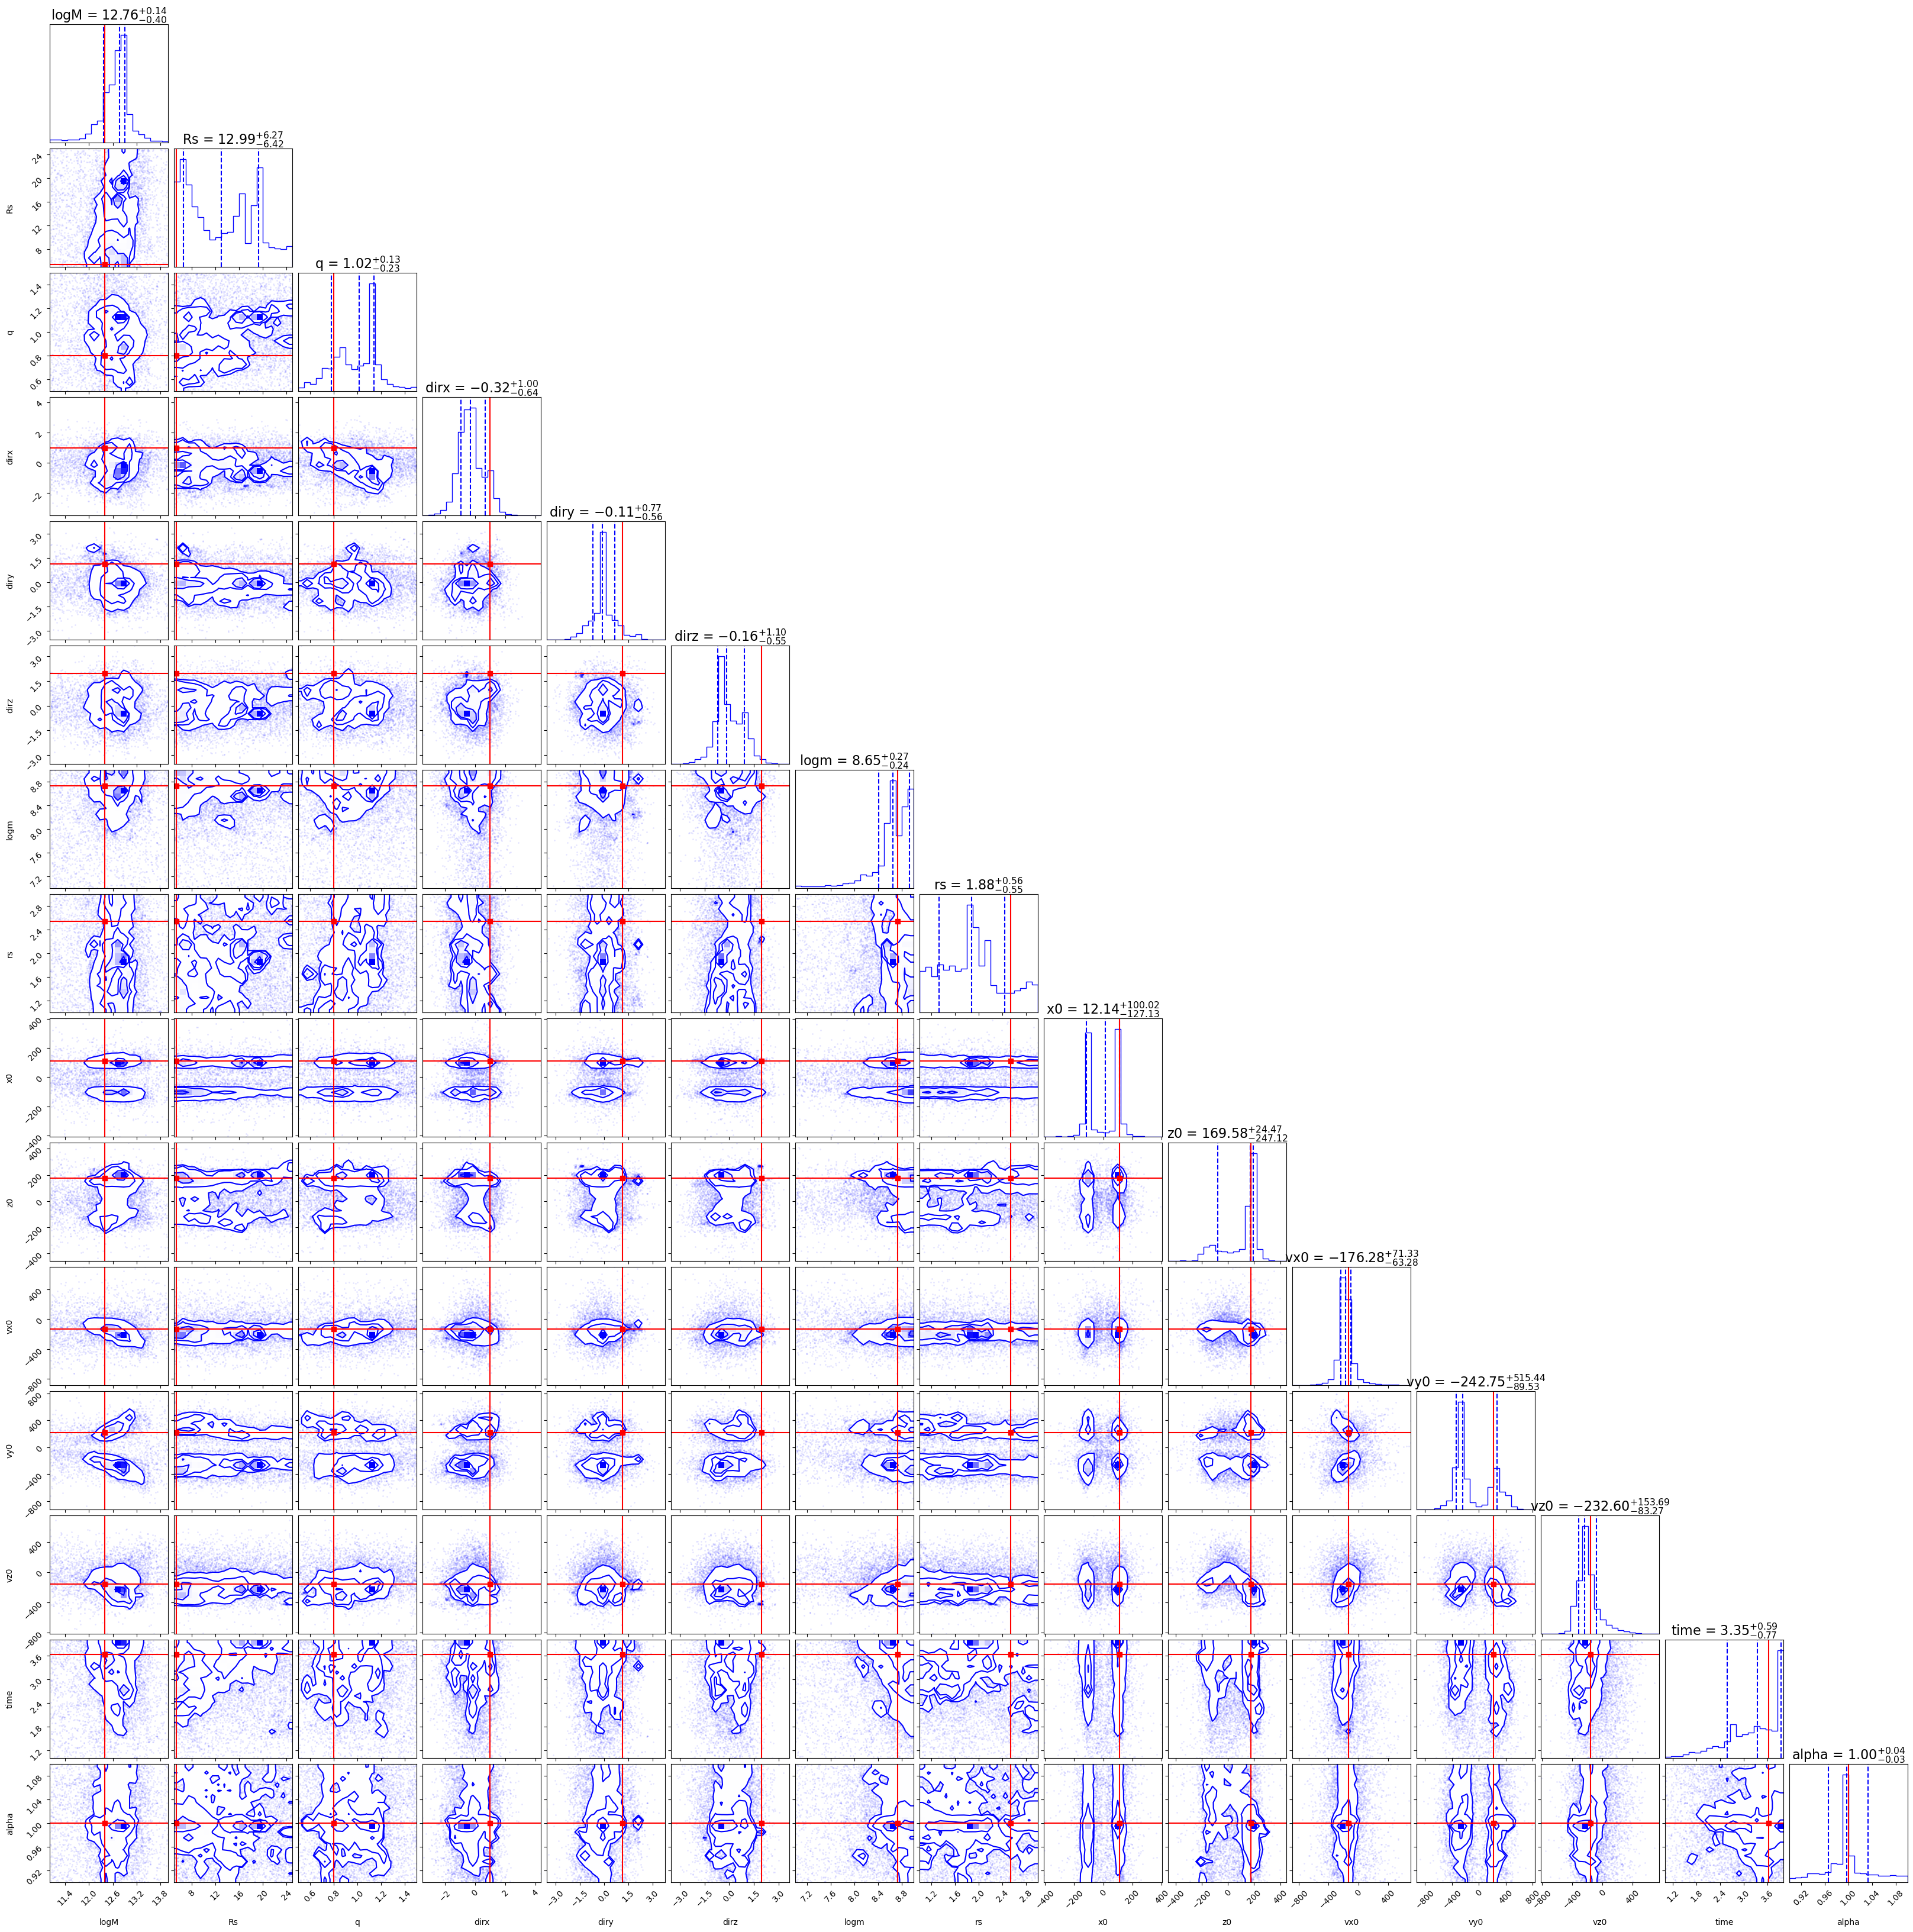

In [36]:
labels = ['logM', 'Rs', 'q', 'dirx', 'diry', 'dirz', 'logm', 'rs', 'x0', 'z0', 'vx0', 'vy0', 'vz0', 'time', 'alpha']
ground_truth = np.concatenate( [dict_data['params'], [1]])
figure = corner.corner(samps_500, 
            labels=labels,
            color='blue',
            quantiles=[0.16, 0.5, 0.84],
            show_titles=True, 
            title_kwargs={"fontsize": 16},
            truths=ground_truth, 
            truth_color='red')
plt.savefig(f'plots/corner_q0.8_sig1_seed42_nlive500.pdf')

### Plot the best fits ###

In [11]:
logl_100, logl_500 = [], []
for i in tqdm(range(len(samps_500)), leave=True):
    if i < len(samps_100):
        logl_100.append(loglikelihood(samps_100[i], dict_data))
    logl_500.append(loglikelihood(samps_500[i], dict_data))
logl_100 = np.array(logl_100)
logl_500 = np.array(logl_500)

100%|██████████| 16000/16000 [36:52<00:00,  7.23it/s] 


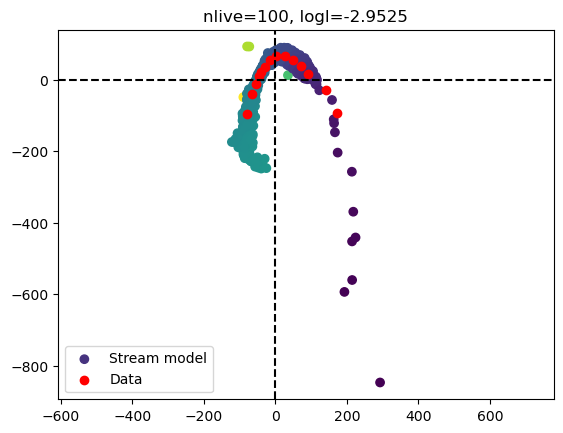

In [37]:
logM, Rs, q, dirx, diry, dirz, logm, rs, x0, z0, vx0, vy0, vz0, time, alpha = samps_100[np.argmax(logl_100)]
dirz = jnp.abs(dirz)
x0   = jnp.abs(x0)
y0   = 0.0
z0   = jnp.abs(z0)
vy0  = jnp.abs(vy0)
theta_stream, x_stream, y_stream, vz_stream, r_meds, w_meds, x_meds, y_meds, vz_meds = jax_stream_model(logM, Rs, q, dirx, diry, dirz, logm, rs, x0, y0, z0, vx0, vy0, vz0, time, alpha, tail=1, min_count=11)

plt.title(f'nlive=100, logl={np.max(logl_100):.4f}')
plt.scatter(x_stream, y_stream, c=theta_stream, label='Stream model')
plt.scatter(dict_data['x_meds'], dict_data['y_meds'], c='r', label='Data')
plt.legend(loc='best')
plt.axis('equal')
plt.axvline(0, c='k', ls='--')
plt.axhline(0, c='k', ls='--')
plt.savefig(f'plots/best_fit_q0.8_sig1_seed42_nlive100.pdf')

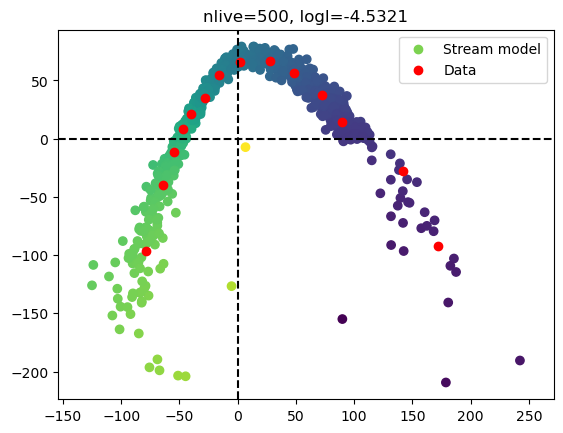

In [38]:
logM, Rs, q, dirx, diry, dirz, logm, rs, x0, z0, vx0, vy0, vz0, time, alpha = samps_500[np.argmax(logl_500)]
dirz = jnp.abs(dirz)
x0   = jnp.abs(x0)
y0   = 0.0
z0   = jnp.abs(z0)
vy0  = jnp.abs(vy0)
theta_stream, x_stream, y_stream, vz_stream, r_meds, w_meds, x_meds, y_meds, vz_meds = jax_stream_model(logM, Rs, q, dirx, diry, dirz, logm, rs, x0, y0, z0, vx0, vy0, vz0, time, alpha, tail=1, min_count=11)

plt.title(f'nlive=500, logl={np.max(logl_500):.4f}')
plt.scatter(x_stream, y_stream, c=theta_stream, label='Stream model')
plt.scatter(dict_data['x_meds'], dict_data['y_meds'], c='r', label='Data')
plt.legend(loc='best')
plt.axis('equal')
plt.axvline(0, c='k', ls='--')
plt.axhline(0, c='k', ls='--')
plt.savefig(f'plots/best_fit_q0.8_sig1_seed42_nlive500.pdf')